# FINDING REGIMES

## Data Preparation

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from numba import njit

In [2]:
ticker = "AAPL"  # Apple
data = yf.download(ticker, start="2015-01-01", end="2024-01-01")

/tmp/ipykernel_9539/3590358442.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2015-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed


In [3]:
prices = data["Close"]
# returns: logarithmic ratio of current versus previous prices
returns = np.log(prices / prices.shift(1))
# dropping the na values
returns = returns.dropna()
# flattening the array
returns = returns.values.flatten()

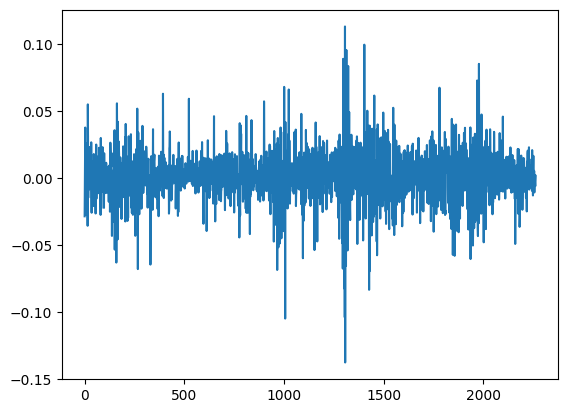

In [4]:
plt.plot(returns)
plt.show()

In [21]:
# -----------------------------------
# GLOBAL STORAGE
# -----------------------------------

regimes = []
regimes_mean = []
regimes_std = []

position = 0
regime_pos = 0

In [22]:
window_size = 10
window = np.empty(0, dtype=returns.dtype)

In [23]:
len(window)

0

In [24]:
minimum_remaining = 3

## Generate Regime

*   Is used to extract data from the returns array append it to the regimes list.
*   Appends regime's mean and std deviation to their respective lists.
*   Once done, the global position is updated to represent how many values have already been retrieved.
*   Is used as the base information used for comparison.



In [87]:

# -----------------------------------
# REGIME GENERATION FUNCTION
# -----------------------------------

def generate_regime(returns, position, regime_size):

    # create regime
    # Correctly extract numerical values from the returns DataFrame slice
    current_regime = returns[position : position + regime_size].tolist()

    # store regime
    regimes.append(current_regime)

    # compute metrics
    current_mean = np.mean(current_regime)
    current_std = np.std(current_regime)

    # store metrics
    regimes_mean.append(current_mean)
    regimes_std.append(current_std)

    # update position
    new_position = position + regime_size

    return new_position

In [9]:
regime_size = 20
position = generate_regime(
    returns,
    position,
    regime_size
)

In [10]:
print(regimes_mean)
print(regimes_std)
print(regimes[0])
print(position)

[np.float64(0.004081928575422529)]
[np.float64(0.02305649560874568)]
[-0.028576073580153523, 9.402015210045412e-05, 0.013924973494412598, 0.037702592749617674, 0.0010719249345452343, -0.02494957890877185, 0.008839669225718688, -0.0038179815990134593, -0.027515123491428078, -0.007800486851824625, 0.025431239205089898, 0.007605040243835667, 0.02568294894491899, 0.005147137621528667, 0.0010612836991739094, -0.03564057646111359, 0.05499267800475843, 0.03065850119663254, -0.014742378635761444, 0.012468761564184394]
20


## Generate window



*   Basically it first checks whether the window array already holds any values or not.
*   After that, it adds fresh values from returns array starting from the position. This helps as we do not add the same values as those already in the regime back to the window.
*  We fill until all slots are filled so that the window size becomes equal to window size.



In [16]:
@njit
def generate_window(returns,
                    position,
                    window_size,
                    window):

    current_residual_len = len(window)
    slots_to_fill = window_size - current_residual_len

    # If the window is already full, compute statistics and return
    if slots_to_fill <= 0:
        window_mean = np.mean(window)
        window_std  = np.std(window)
        return window, window_mean, window_std, position

    top_up_end_idx = position + slots_to_fill

    # Defensive guard for the end of the data array
    if top_up_end_idx > len(returns):
        slots_to_fill = len(returns) - position
        top_up_end_idx = len(returns)

    fresh_inputs = returns[position:top_up_end_idx]

    # Create a fresh container matching the exact size and format required
    updated_window = np.empty(window_size, dtype=returns.dtype)

    # Place the surviving residual values at the front slots
    updated_window[:current_residual_len] = window

    # Place the fresh inputs directly behind them into the empty slots
    updated_window[current_residual_len : current_residual_len + len(fresh_inputs)] = fresh_inputs

    # Advance the reading pointer position by exactly what was pulled
    position = top_up_end_idx

    # Compute your window statistics from the newly completed uniform array
    window_mean = np.mean(updated_window)
    window_std  = np.std(updated_window)

    return updated_window, window_mean, window_std, position

In [17]:
window, window_mean, window_std,position = generate_window(
    returns,
    position,
    window_size,
    window
)

print("window:", window)
print("window_mean:", window_mean)
print("window_std:", window_std)
print("position:", position)

window: [ 0.00016899  0.00763996  0.00711206 -0.00845658  0.00662072  0.01902928
  0.02316847  0.01257293  0.00489035  0.00588448]
window_mean: 0.0078630664002658
window_std: 0.008494477305161636
position: 30


##  Adaptive Distance Signal Mapping
To detect structural regime changes sequentially without look-ahead bias, we track the statistical distance ($\delta$) between the incoming look-ahead window and the active historical regime.

The standardized distance is calculated as:
$$\delta = \frac{|\mu_{\text{window}} - \mu_{\text{regime}}|}{\sigma_{\text{regime}} + \epsilon}$$

We then map this distance to a bounded $[0, 1]$ probability space using an exponential cumulative distribution shape controlled by a hyperparameter $\alpha$:
$$\text{Signal Strength} = 1 - e^{-\alpha \cdot \delta}$$

This provides an ultra-responsive threshold trigger that scales dynamically based on the active regime's localized volatility, ensuring the engine stays sensitive to micro-shocks during stable market phases while avoiding unnecessary triggers during high-volatility regimes.

In [64]:
@njit
def signal(regime_mean, regime_std, remaining_window_mean, remaining_window_std, regime_len, window_len):
    epsilon = 1e-6

    # Combined standard error of the difference between two independent means
    pooled_se = np.sqrt((regime_std**2 / regime_len) + (remaining_window_std**2 / window_len)) + epsilon

    # Calculate absolute t-stat
    t_stat = abs(remaining_window_mean - regime_mean) / pooled_se

    # Map to [0,1] probability range using a simple hyperbolic tangent (tanh)
    # instead of exp() for cleaner hardware boundary convergence
    signal_strength = np.tanh(t_stat / 2.0)

    return signal_strength

## Refine Boundary


*   This helps check all the values in the window that fall under the same regime
*   For that we remove one value at a time from the window array. Then for each iteration we check the signal which tells how similar is the window compared to pervious regime. We remove values from the left as these are the values closest the previous regime.
*   For the remaining values in the window, when the signal exceeds a boundary threshold it implies that it is highly probable that now the remaining values are not from the same regime anymore.



In [19]:
# ---------------------------------------------------------
# BOUNDARY REFINEMENT FUNCTION
# Uses PRECOMPUTED signals
# ---------------------------------------------------------

@njit
def refine_boundary(window,
                    regime_mean,
                    regime_std,
                    window_mean,
                    boundary_threshold = 0.5):

    n = len(window)

    boundary_index = 0

    # -------------------------------------------------
    # LEFT TRIMMING PROCESS
    # -------------------------------------------------

    for i in range(n):

        # remaining section
        remaining_window = window[i:]

        # compute size of remaining window
        remaining_size = len(remaining_window)

        # compute stats of remaining window
        remaining_mean = np.sum(remaining_window)/n
        remaining_std = np.std(remaining_window)

        # compute signal of remaining window
        remaining_signal = singal(regime_mean, regime_std,remaining_mean,remaining_std)

        # -------------------------------------------------
        # Strong drift detected
        # -------------------------------------------------

        if remaining_signal < boundary_threshold:
            boundary_index = i
            continue
        elif remaining_signal > boundary_threshold:
            break

    return boundary_index

In [20]:
boundary = refine_boundary(
    window,
    regimes_mean[-1],
    regimes_std[-1],
    window_mean
)
print(boundary)
regime_window = window[:boundary+1]
print(regime_window)
window = window[boundary+1:]
print(window)

9
[ 0.00016899  0.00763996  0.00711206 -0.00845658  0.00662072  0.01902928
  0.02316847  0.01257293  0.00489035  0.00588448]
[]


### 2. Sequential Streaming State Machine & Memory Management
Financial time-series data is non-stationary. Standard clustering algorithms (like K-Means or basic HMMs) suffer from look-ahead bias or extreme over-segmentation, splitting the timeline into fragmented, unreadable "barcode" regions.

This pipeline implements a custom sequential state buffer execution loop to resolve these traps:
1. **Dynamic Top-Up:** It streams returns sequentially into a look-ahead window using a localized `generate_window` helper.
2. **Memory-Capped Anchoring (Anti-Dilution):** As a regime grows, old historical data points can dilute the metrics, making the engine "immune" to sudden late-stage crashes. To prevent this statistical dilution, the baseline parameters ($\mu$ and $\sigma$) are strictly calculated over a rolling maximum look-back anchor of the last 100 elements:
```python
active_regime_tail = np.array(regimes[-1][-100:])

In [77]:
def pipeline(returns,
             regimes,
             regimes_mean,
             regimes_std,
             window,
             position,
             regime_pos,
             regime_size = 20,
             window_size = 10,
             minimum_remaining = 3,
             boundary_threshold = 0.5):

    # -----------------------------------------------------------------
    # STAGE 1: INITIAL ANCHOR SEEDING
    # -----------------------------------------------------------------
    if position == 0:
        position = generate_regime(returns, position, regime_size)
        regime_pos += position
        window = np.empty(0, dtype=returns.dtype)

    # -----------------------------------------------------------------
    # STAGE 2: SEQUENTIAL STREAMING LOOP
    # -----------------------------------------------------------------
    while position < len(returns):
        if position + window_size > len(returns):
            break

        window, window_mean, window_std, position = generate_window(
            returns, position, window_size, window
        )

        boundary = refine_boundary(
            window,
            regimes_mean[-1],
            regimes_std[-1],
            window_mean,
            boundary_threshold
        )

        regime_window = window[:boundary+1]

        # 1. Extend the active regime list
        regimes[-1].extend(regime_window.tolist())

        # --- FIXED: MEMORY-CAPPED / RESPONSIVE BASELINE ---
        # Slices only the last 100 elements of the active regime to calculate metrics
        # This prevents old history from diluting new volatility shocks
        active_regime_tail = np.array(regimes[-1][-100:], dtype=returns.dtype)
        regimes_mean[-1] = np.mean(active_regime_tail)
        regimes_std[-1] = np.std(active_regime_tail)

        regime_pos += len(regime_window)

        # 2. Decide whether to spawn a new regime or roll over the window tail
        if window_size - len(regime_window) > minimum_remaining:
            remainder_window = window[boundary+1:]

            # Spawn a brand new regime block
            regimes.append(remainder_window.tolist())

            # Crucial: Instantly append the matching metrics so lists stay synchronized
            regimes_mean.append(np.mean(remainder_window))
            regimes_std.append(np.std(remainder_window))

            window = np.empty(0, dtype=returns.dtype)
        else:
            # Shift the window buffer forward (the active regime metrics are updated on the next pass)
            window = window[boundary+1:]

    return regimes, regimes_mean, regimes_std, regime_pos

In [82]:
# 1. Clear out your tracking arrays
regimes = []
regimes_mean = []
regimes_std = []
position = 0
regime_pos = 0
window = np.empty(0, dtype=returns.dtype)

# 2. Execute with a softer, accessible threshold and stable windows
regimes, regimes_mean, regimes_std, regime_pos = pipeline(
    returns=returns,
    regimes=regimes,
    regimes_mean=regimes_mean,
    regimes_std=regimes_std,
    window=window,
    position=position,
    regime_pos=regime_pos,
    regime_size=30,            # Clean initial profile baseline
    window_size=20,            # Wide enough to filter noise, short enough to find boundaries
    minimum_remaining=5,       # Keeps anchor blocks statistically valid
    boundary_threshold=0.35    # Dropped lower so your exponential function can easily bridge it
)



### 3. Regime Visualization & Volatility Mapping
The final visualization maps the underlying asset's cumulative log performance and segments the timeline by color-shading the background canvas according to each distinct regime's calculated standard deviation ($\sigma$).

* **Cool/Pale Shading (Low $\sigma$):** Represents institutional grind phases where variance is low and steady.
* **Warm/Deep Red Shading (High $\sigma$):** Represents macro structural breaks, downside panics, or high-velocity volatility expansions.

Because the state machine preserves strict chronology, the resulting visualization cleanly captures macro-economic cycles and immediate volatility inflections with precise boundary alignment and zero look-ahead distortion.

Total return data points: 2263
Total tracked regimes: 31
Total metrics in regimes_std: 31


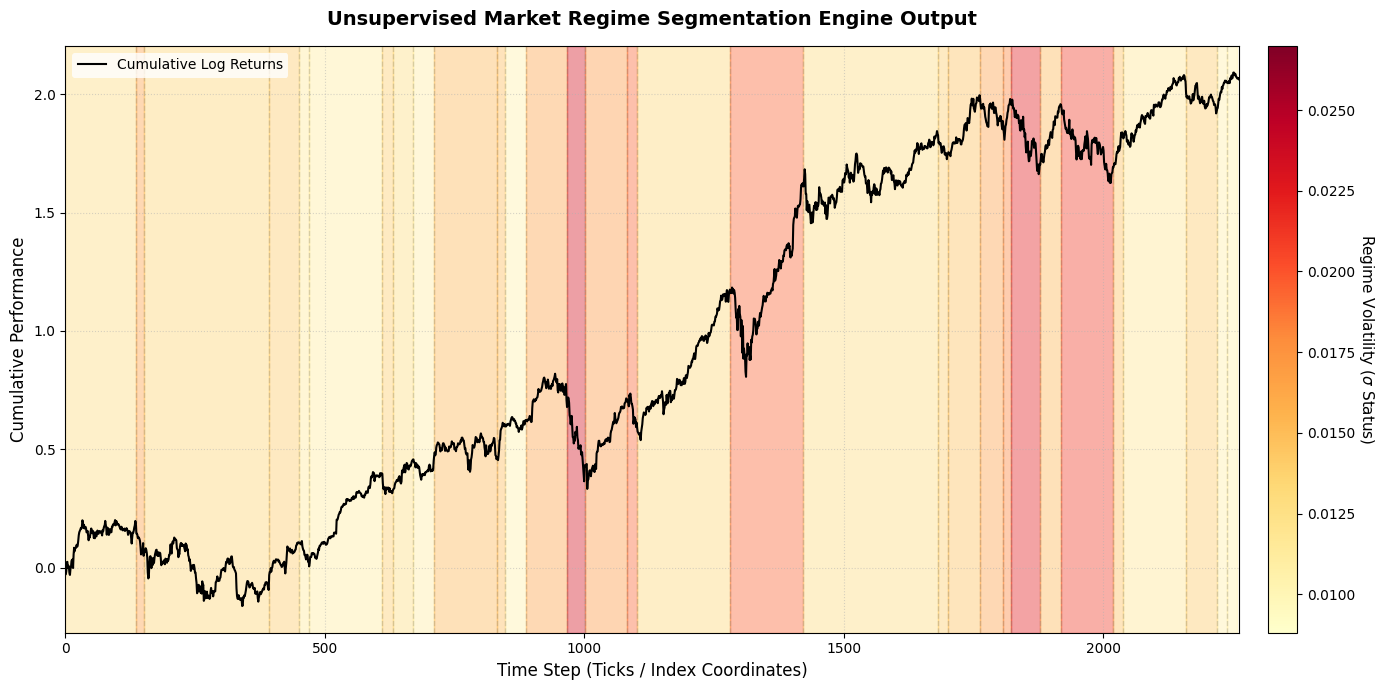

In [85]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_market_regimes(returns, regimes, regimes_std):
    """
    Plots cumulative asset returns and color-codes the background
    by the identified regime's volatility standard deviation.
    """
    # --- SANITY CHECK PRINTS ---
    print(f"Total return data points: {len(returns)}")
    print(f"Total tracked regimes: {len(regimes)}")
    print(f"Total metrics in regimes_std: {len(regimes_std)}")

    if len(regimes) == 0 or len(returns) == 0:
        print("❌ Error: 'returns' or 'regimes' data is empty. Run your pipeline cell first!")
        return

    # 1. Reconstruct the full time series timeline
    cumulative_returns = np.cumsum(returns)
    total_points = len(returns)

    # Create the figure canvas explicitly
    fig, ax = plt.subplots(figsize=(15, 7))

    # 2. Plot underlying asset data line
    ax.plot(cumulative_returns, color='black', linewidth=1.5, label='Cumulative Log Returns', zorder=3)

    # 3. Setup color mapping metrics safely
    current_global_idx = 0
    min_std = min(regimes_std) if regimes_std else 0
    max_std = max(regimes_std) if regimes_std else 1
    std_range = max_std - min_std if max_std != min_std else 1

    # Updated to use modern matplotlib syntax to clear deprecation warnings
    cmap = plt.get_cmap('YlOrRd')

    # 4. Step through flat regimes and shade the background canvas
    for i, regime in enumerate(regimes):
        regime_len = len(regime)
        start_idx = current_global_idx
        end_idx = current_global_idx + regime_len

        # Guard rails to make sure index bounds stay inside the returns size
        if start_idx >= total_points:
            break
        if end_idx > total_points:
            end_idx = total_points

        # Calculate a normalized intensity score between 0 and 1 for this regime's volatility
        normalized_vol = (regimes_std[i] - min_std) / std_range if std_range != 0 else 0.5

        # Fetch the corresponding background color (with transparency alpha)
        bg_color = cmap(normalized_vol * 0.7 + 0.1)

        # Shade the background span for this specific regime's duration
        ax.axvspan(start_idx, end_idx, color=bg_color, alpha=0.4, zorder=1)

        # Draw a subtle vertical dashed line showing the exact break boundary point
        if i < len(regimes) - 1 and end_idx < total_points:
            ax.axvline(x=end_idx, color='gray', linestyle='--', alpha=0.3, linewidth=1, zorder=2)

        current_global_idx = end_idx

    # 5. Add professional styling and labels
    ax.set_title('Unsupervised Market Regime Segmentation Engine Output', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Time Step (Ticks / Index Coordinates)', fontsize=12)
    ax.set_ylabel('Cumulative Performance', fontsize=12)
    ax.set_xlim(0, total_points)
    ax.grid(True, linestyle=':', alpha=0.5, zorder=0)

    # Add a colorbar legend to decode the background shading intensity
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmax=max_std, vmin=min_std))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, pad=0.02)

    # Added raw string 'r' prefix to completely eliminate the '\s' syntax warning
    cbar.set_label(r'Regime Volatility ($\sigma$ Status)', rotation=270, labelpad=15, fontsize=11)

    ax.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()

    # Force drawing/rendering commands explicitly
    plt.draw()
    plt.show()

# --- EXECUTION ORDER CHECK ---
# Make sure your pipeline step matches this sequence exactly:
# 1. Reset arrays to []
# 2. Run your pipeline code function
# 3. Call this function right below it:
visualize_market_regimes(returns, regimes, regimes_std)